# Gradient Boosting Machine (GBM) Tutorial

Gradient Boosting builds trees sequentially, where each tree is trained to predict the residuals (errors) of the preceding trees. It uses a gradient descent algorithm to minimize a loss function (like log-loss for classification or MSE for regression) when adding new models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, log_loss

sns.set_theme(style='whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
df = pd.read_csv('../../Datasets/diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Data loaded and split.')

Data loaded and split.


In [3]:
# Train GradientBoostingClassifier
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm.fit(X_train, y_train)

y_pred = gbm.predict(X_test)
y_pred_proba = gbm.predict_proba(X_test)[:, 1]

print(f'GBM Train Accuracy: {gbm.score(X_train, y_train):.4f}')
print(f'GBM Test Accuracy: {gbm.score(X_test, y_test):.4f}')

GBM Train Accuracy: 0.9186
GBM Test Accuracy: 0.7532


In [4]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}')

Confusion Matrix:
[[84 16]
 [22 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

ROC-AUC Score: 0.8422


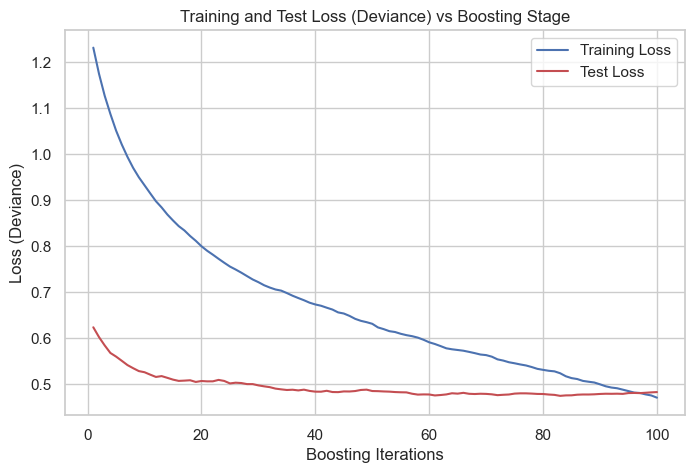

In [5]:
# Compute validation loss (deviance) at each stage
test_score = np.zeros((100,), dtype=np.float64)
for i, y_pred_stage in enumerate(gbm.staged_predict_proba(X_test)):
    # log_loss takes y_test and predicted probabilities
    test_score[i] = log_loss(y_test, y_pred_stage)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(100) + 1, gbm.train_score_, 'b-', label='Training Loss')
plt.plot(np.arange(100) + 1, test_score, 'r-', label='Test Loss')
plt.title('Training and Test Loss (Deviance) vs Boosting Stage')
plt.xlabel('Boosting Iterations')
plt.ylabel('Loss (Deviance)')
plt.legend(loc='upper right')
plt.show()

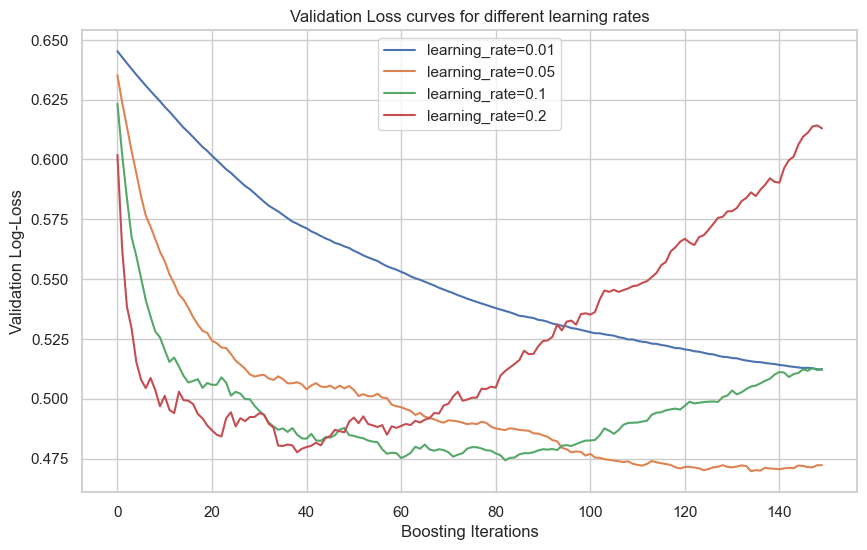

In [6]:
rates = [0.01, 0.05, 0.1, 0.2]
plt.figure(figsize=(10, 6))

for rate in rates:
    model = GradientBoostingClassifier(n_estimators=150, learning_rate=rate, random_state=42)
    model.fit(X_train, y_train)
    
    # Get staged loss for validation set
    val_loss = [log_loss(y_test, pred) for pred in model.staged_predict_proba(X_test)]
    plt.plot(val_loss, label=f'learning_rate={rate}')

plt.title('Validation Loss curves for different learning rates')
plt.xlabel('Boosting Iterations')
plt.ylabel('Validation Log-Loss')
plt.legend()
plt.show()

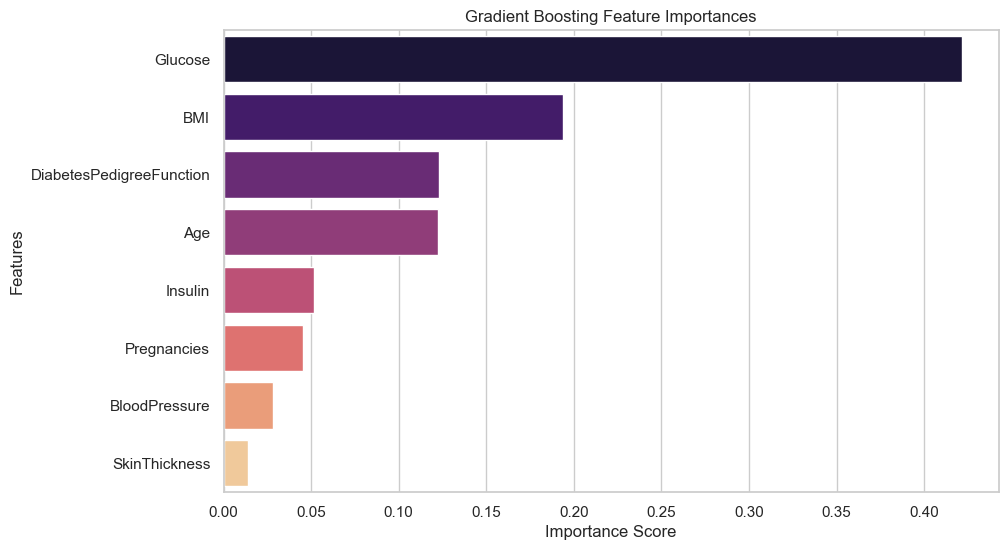

In [7]:
importances = gbm.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Gradient Boosting Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Key Takeaways:
1. Gradient Boosting builds trees sequentially to minimize the gradient of the loss function.
2. The learning rate scales the contribution of each tree. Smaller learning rates require more estimators but often generalize better.
3. Staged loss analysis helps us detect overfitting and choose the optimal number of estimators.